# Two-Stream ST-GCN — Depth Search on FX Subset

Mục tiêu: tìm độ sâu (số block) phù hợp nhất cho Two-Stream ST-GCN trên tập FX (35 classes), nơi mô hình depth=10 bị overfit.

| Depth | Blocks per stream | ~Params (2 streams) | Ghi chú |
|-------|------------------|---------------------|---------|
| 10    | 64×4 → 128×3 → 256×3 | ~6.2M | Baseline, đang overfit |
| 8     | 64×3 → 128×2 → 256×3 | ~5.5M | Giảm nhẹ |
| 6     | 64×2 → 128×2 → 256×2 | ~4.5M | Compact |
| 4     | 64×1 → 128×1 → 256×2 | ~3.2M | Lightweight |

**Pipeline:**
```
Gym288 → build Gym99 → lọc FX (35 cls) → train 4 variants → so sánh train/val curves
```

**Config chung cho tất cả depths:**
- Apparatus: FX, 35 classes (label 6–40 → local 0–34)
- Joint spec: COCO18
- Loss: Focal (sqrt_inverse alpha)
- Augmentation: SkeletonFeeder + WeightedRandomSampler
- Normalization: center_norm
- Model: `--use_two_stream` với từng `--model_depth`

In [1]:
# ── Cell 1: Environment & paths ───────────────────────────────────────────────
import os
import subprocess
import sys
from pathlib import Path

try:
    from dotenv import load_dotenv
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-dotenv', '-q'], check=True)
    from dotenv import load_dotenv

_nb_dir = Path(globals().get('__vsc_ipynb_file__', __file__) if '__file__' in dir() else '.').resolve().parent
for _candidate in [_nb_dir / '.env', _nb_dir.parent / '.env', Path('.env')]:
    if _candidate.exists():
        load_dotenv(_candidate)
        print(f'Loaded .env from {_candidate}')
        break
else:
    print('No .env found — using Kaggle defaults')

REPO_DIR   = os.getenv('REPO_DIR',   '/kaggle/working/Yolo-ST-GCN')
BRANCH     = os.getenv('BRANCH',     'experiment-bonestream')
GYM288_PKL = os.getenv('GYM288_PKL', '/kaggle/working/Gym288-skeleton/gym_288_skeleton.pkl')
GYM99_PKL  = os.getenv('GYM99_PKL',  '/kaggle/working/Gym99-from-Gym288/gym99_from_gym288.pkl')
OUT_BASE   = os.getenv('OUT_DIR',    'outputs/depth_search_fx')

# ── Experiment config ─────────────────────────────────────────────────────────
DEPTHS                  = [8, 6, 4]   # depth=10 already trained separately
EPOCHS                  = 100
BATCH_SIZE              = 64
LR                      = '0.001'
WARMUP_EPOCHS           = '5'
EARLY_STOPPING_PATIENCE = '10'        # stop if val_loss stagnates for 10 epochs (0 = off)
POLICY_PATH             = '/kaggle/working/fx_aug_policy.json'

DEPTH_OUT_DIRS = {d: f'{OUT_BASE}/depth_{d}_2s' for d in DEPTHS}

print(f'REPO_DIR                  = {REPO_DIR}')
print(f'GYM288_PKL                = {GYM288_PKL}')
print(f'GYM99_PKL                 = {GYM99_PKL}')
print(f'OUT_BASE                  = {OUT_BASE}')
print(f'Depths to run             = {DEPTHS}')
print(f'Early stopping patience   = {EARLY_STOPPING_PATIENCE}')

No .env found — using Kaggle defaults
REPO_DIR                  = /kaggle/working/Yolo-ST-GCN
GYM288_PKL                = /kaggle/working/Gym288-skeleton/gym_288_skeleton.pkl
GYM99_PKL                 = /kaggle/working/Gym99-from-Gym288/gym99_from_gym288.pkl
OUT_BASE                  = outputs/depth_search_fx
Depths to run             = [8, 6, 4]
Early stopping patience   = 10


In [2]:
# ── Cell 2: Repo setup ────────────────────────────────────────────────────────
REPO_URL = 'https://github.com/schizocatto/Yolo-ST-GCN.git'

if not Path(REPO_DIR).exists():
    print('Cloning repo...')
    subprocess.run(
        ['git', 'clone', '-b', BRANCH, '--single-branch', REPO_URL, REPO_DIR],
        check=True,
    )
else:
    print('Repo exists — pulling latest...')
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'pull', 'origin', BRANCH], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print('Working dir:', os.getcwd())

Cloning repo...


Cloning into '/kaggle/working/Yolo-ST-GCN'...


Working dir: /kaggle/working/Yolo-ST-GCN


In [3]:
# ── Cell 3: Download Gym288 dataset ───────────────────────────────────────────
if Path(GYM288_PKL).exists():
    print(f'Gym288 pickle found: {GYM288_PKL}')
else:
    print('Downloading from HuggingFace...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'huggingface_hub', '-q'], check=True)
    from huggingface_hub import snapshot_download
    download_dir = Path(GYM288_PKL).parent
    download_dir.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id='Lozumi/Gym288-skeleton',
        repo_type='dataset',
        local_dir=str(download_dir),
        local_dir_use_symlinks=False,
    )
    pkl_candidates = sorted(download_dir.rglob('*.pkl'))
    if not pkl_candidates:
        raise FileNotFoundError('No .pkl found after Gym288 download.')
    GYM288_PKL = str(pkl_candidates[0])
    print(f'Downloaded: {GYM288_PKL}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Downloaded: /kaggle/working/Gym288-skeleton/gym_288_skeleton.pkl


In [4]:
# ── Cell 4: Custom augmentation policy for FX ─────────────────────────────────
import json

fx_policy = {
    "0": {
        "horizontal_flip_prob": 0.5,
        "scale_prob": 0.2,
        "scale_range": [0.95, 1.05],
        "random_shift": False,
        "random_move": False,
        "noise_std": 0.0,
        "joint_drop_prob": 0.0,
        "subsample_prob": 0.0
    },
    "1": {
        "horizontal_flip_prob": 0.5,
        "scale_prob": 0.5,
        "scale_range": [0.9, 1.1],
        "random_shift": True,
        "random_move": True,
        "move_angle": 5.0,
        "move_scale": 0.05,
        "move_trans": 0.0,
        "noise_std": 0.005,
        "joint_drop_prob": 0.05,
        "subsample_prob": 0.3,
        "subsample_factor_range": [0.9, 1.1]
    },
    "2": {
        "horizontal_flip_prob": 0.5,
        "scale_prob": 0.8,
        "scale_range": [0.85, 1.15],
        "random_shift": True,
        "random_move": True,
        "move_angle": 10.0,
        "move_scale": 0.1,
        "move_trans": 0.0,
        "noise_std": 0.01,
        "joint_drop_prob": 0.1,
        "subsample_prob": 0.5,
        "subsample_factor_range": [0.8, 1.2],
        "temporal_reverse_prob": 0.0
    }
}

Path(POLICY_PATH).parent.mkdir(parents=True, exist_ok=True)
with open(POLICY_PATH, 'w') as f:
    json.dump(fx_policy, f, indent=4)

print(f'Augmentation policy saved: {POLICY_PATH}')

Augmentation policy saved: /kaggle/working/fx_aug_policy.json


In [5]:
# ── Cell 5: Train Two-Stream depth=8 ─────────────────────────────────────────
import importlib

DEPTH = 8
OUT   = DEPTH_OUT_DIRS[DEPTH]

_dsuffix   = f'_d{DEPTH}' if DEPTH != 10 else ''
checkpoint = Path(OUT) / f'stgcn_gym99_coco18_2s{_dsuffix}_expert_FX.pth'
if checkpoint.exists():
    print(f'[depth={DEPTH}] Checkpoint found, skipping training: {checkpoint}')
else:
    sys.argv = [
        'train_gym99.py',
        '--auto_build_from_gym288',
        '--gym288_dataset_path',     GYM288_PKL,
        '--dataset_path',            GYM99_PKL,
        '--out_dir',                 OUT,
        '--apparatus',               'FX',
        '--epochs',                  str(EPOCHS),
        '--batch_size',              str(BATCH_SIZE),
        '--lr',                      LR,
        '--warmup_epochs',           WARMUP_EPOCHS,
        '--early_stopping_patience', EARLY_STOPPING_PATIENCE,
        '--num_workers',             '2',
        '--joint_spec_name',         'coco18',
        '--use_two_stream',
        '--model_depth',             str(DEPTH),
        '--loss_name',               'focal',
        '--focal_alpha_mode',        'sqrt_inverse',
        '--center_norm',
        '--use_augment_feeder',
        '--aug_config_path',         POLICY_PATH,
        '--use_weighted_sampler',
        '--grad_clip_norm',          '1.0',
        '--weight_decay',            '0.0005',
        '--save_every_epochs',       '10',
    ]
    import scripts.train_gym99 as _train
    importlib.reload(_train)
    print(f'>>> Training Two-Stream depth={DEPTH} on FX (35 classes)...')
    _train.main()
    print(f'\n✅ depth={DEPTH} done.')

>>> Training Two-Stream depth=8 on FX (35 classes)...
Building Gym99-from-Gym288 pickle...
Gym99 mapping stats: direct=34240 minus1=1625 plus1=800 train=27624 test=9041
Device: cuda
Loading Gym99-skeleton dataset...
[apparatus=FX] class range [6, 40] → local classes [0, 34]  train=5824  val=2411
[corrupt filter] train: 5824 → 5280 (removed 544)
[corrupt filter] val:   2411 → 2181 (removed 230)
Loaded 36665 samples  train=5280  test=2181
[info] Applying per-frame center normalization (center joint = 17)...
num_classes=35 (apparatus=FX, local labels 0-34)
[info] Using in-memory tensors; forcing num_workers=0 to avoid dataloader overhead.
[info] Loaded custom augmentation policy from: /kaggle/working/fx_aug_policy.json

[SkeletonFeeder] Augmentation tier assignment (35 classes, 5280 samples)
  Tier 0 [Majority (light)] — 18 classes, 3928 samples (74.4%)
      class   16: 130 samples
      class    1: 131 samples
      class   19: 132 samples
      class   15: 132 samples
      class   25:


Epoch 1/100 [train]: 100%|██████████| 83/83 [00:30<00:00,  3.18it/s]
                                                                    
Epoch 1/100 [val]:  97%|█████████▋| 34/35 [00:02<00:00, 12.05it/s]
                                                                  

Epoch 1/100  train_loss=3.1745  train_acc=0.0723  val_loss=2.4606  val_acc=0.0798  val_f1=0.0480



Epoch 2/100 [train]: 100%|██████████| 83/83 [00:30<00:00,  3.12it/s]
                                                                    
Epoch 2/100 [val]:  97%|█████████▋| 34/35 [00:03<00:00, 10.98it/s]
                                                                  

Epoch 2/100  train_loss=1.8220  train_acc=0.2570  val_loss=1.2569  val_acc=0.2696  val_f1=0.2985


...

Epoch 65/100  train_loss=0.0396  train_acc=0.9710  val_loss=0.1825  val_acc=0.8702  val_f1=0.8502



Epoch 66/100 [train]: 100%|██████████| 83/83 [00:33<00:00,  2.91it/s]
                                                                     
Epoch 66/100 [val]:  97%|█████████▋| 34/35 [00:03<00:00, 10.38it/s]
                                                                   

Epoch 66/100  train_loss=0.0387  train_acc=0.9684  val_loss=0.1812  val_acc=0.8776  val_f1=0.8560



Epoch 67/100 [train]: 100%|██████████| 83/83 [00:32<00:00,  2.88it/s]
                                                                     
Epoch 67/100 [val]:  97%|█████████▋| 34/35 [00:03<00:00, 10.34it/s]
                                                                   

Epoch 67/100  train_loss=0.0329  train_acc=0.9701  val_loss=0.1788  val_acc=0.8757  val_f1=0.8580
[early stopping] No val_loss improvement for 10 epochs. Stopping at epoch 67.
[early stopping] Restored best weights (val_loss=0.1788)
Saved weights: outputs/depth_search_fx/depth_8_2s/stgcn_gym99_coco18_2s_d8_expert_FX.pth
Test Top-1 Accuracy: 0.8698
Test Macro-F1     : 0.8459

✅ depth=8 done.


In [6]:
# ── Cell 6: Train Two-Stream depth=6 ─────────────────────────────────────────
import importlib

DEPTH = 6
OUT   = DEPTH_OUT_DIRS[DEPTH]

_dsuffix   = f'_d{DEPTH}' if DEPTH != 10 else ''
checkpoint = Path(OUT) / f'stgcn_gym99_coco18_2s{_dsuffix}_expert_FX.pth'
if checkpoint.exists():
    print(f'[depth={DEPTH}] Checkpoint found, skipping training: {checkpoint}')
else:
    sys.argv = [
        'train_gym99.py',
        '--auto_build_from_gym288',
        '--gym288_dataset_path',     GYM288_PKL,
        '--dataset_path',            GYM99_PKL,
        '--out_dir',                 OUT,
        '--apparatus',               'FX',
        '--epochs',                  str(EPOCHS),
        '--batch_size',              str(BATCH_SIZE),
        '--lr',                      LR,
        '--warmup_epochs',           WARMUP_EPOCHS,
        '--early_stopping_patience', EARLY_STOPPING_PATIENCE,
        '--num_workers',             '2',
        '--joint_spec_name',         'coco18',
        '--use_two_stream',
        '--model_depth',             str(DEPTH),
        '--loss_name',               'focal',
        '--focal_alpha_mode',        'sqrt_inverse',
        '--center_norm',
        '--use_augment_feeder',
        '--aug_config_path',         POLICY_PATH,
        '--use_weighted_sampler',
        '--grad_clip_norm',          '1.0',
        '--weight_decay',            '0.0005',
        '--save_every_epochs',       '10',
    ]
    import scripts.train_gym99 as _train
    importlib.reload(_train)
    print(f'>>> Training Two-Stream depth={DEPTH} on FX (35 classes)...')
    _train.main()
    print(f'\n✅ depth={DEPTH} done.')

>>> Training Two-Stream depth=6 on FX (35 classes)...
Building Gym99-from-Gym288 pickle...
Gym99 mapping stats: direct=34240 minus1=1625 plus1=800 train=27624 test=9041
Device: cuda
Loading Gym99-skeleton dataset...
[apparatus=FX] class range [6, 40] → local classes [0, 34]  train=5824  val=2411
[corrupt filter] train: 5824 → 5280 (removed 544)
[corrupt filter] val:   2411 → 2181 (removed 230)
Loaded 36665 samples  train=5280  test=2181
[info] Applying per-frame center normalization (center joint = 17)...
num_classes=35 (apparatus=FX, local labels 0-34)
[info] Using in-memory tensors; forcing num_workers=0 to avoid dataloader overhead.
[info] Loaded custom augmentation policy from: /kaggle/working/fx_aug_policy.json

[SkeletonFeeder] Augmentation tier assignment (35 classes, 5280 samples)
  Tier 0 [Majority (light)] — 18 classes, 3928 samples (74.4%)
      class   16: 130 samples
      class    1: 131 samples
      class   19: 132 samples
      class   15: 132 samples
      class   25:


Epoch 1/100 [train]: 100%|██████████| 83/83 [00:27<00:00,  3.42it/s]
                                                                    
Epoch 1/100 [val]:  97%|█████████▋| 34/35 [00:02<00:00, 12.04it/s]
                                                                  

Epoch 1/100  train_loss=3.2418  train_acc=0.0555  val_loss=2.5458  val_acc=0.0834  val_f1=0.0896



Epoch 2/100 [train]: 100%|██████████| 83/83 [00:27<00:00,  3.64it/s]
                                                                    
Epoch 2/100 [val]:  97%|█████████▋| 34/35 [00:02<00:00, 13.77it/s]
                                                                  

Epoch 2/100  train_loss=1.9958  train_acc=0.2345  val_loss=1.4462  val_acc=0.2393  val_f1=0.2718


...

Epoch 91/100  train_loss=0.0117  train_acc=0.9947  val_loss=0.1793  val_acc=0.8877  val_f1=0.8585



Epoch 92/100 [train]: 100%|██████████| 83/83 [00:26<00:00,  3.68it/s]
                                                                     
Epoch 92/100 [val]:  97%|█████████▋| 34/35 [00:02<00:00, 13.45it/s]
                                                                   

Epoch 92/100  train_loss=0.0129  train_acc=0.9936  val_loss=0.1725  val_acc=0.8932  val_f1=0.8693



Epoch 93/100 [train]: 100%|██████████| 83/83 [00:26<00:00,  3.60it/s]
                                                                     
Epoch 93/100 [val]:  97%|█████████▋| 34/35 [00:02<00:00, 13.56it/s]
                                                                   

Epoch 93/100  train_loss=0.0111  train_acc=0.9949  val_loss=0.1753  val_acc=0.8968  val_f1=0.8724
[early stopping] No val_loss improvement for 10 epochs. Stopping at epoch 93.
[early stopping] Restored best weights (val_loss=0.1702)
Saved weights: outputs/depth_search_fx/depth_6_2s/stgcn_gym99_coco18_2s_d6_expert_FX.pth
Test Top-1 Accuracy: 0.8945
Test Macro-F1     : 0.8719

✅ depth=6 done.


In [7]:
# ── Cell 7: Train Two-Stream depth=4 ─────────────────────────────────────────
import importlib

DEPTH = 4
OUT   = DEPTH_OUT_DIRS[DEPTH]

_dsuffix   = f'_d{DEPTH}' if DEPTH != 10 else ''
checkpoint = Path(OUT) / f'stgcn_gym99_coco18_2s{_dsuffix}_expert_FX.pth'
if checkpoint.exists():
    print(f'[depth={DEPTH}] Checkpoint found, skipping training: {checkpoint}')
else:
    sys.argv = [
        'train_gym99.py',
        '--auto_build_from_gym288',
        '--gym288_dataset_path',     GYM288_PKL,
        '--dataset_path',            GYM99_PKL,
        '--out_dir',                 OUT,
        '--apparatus',               'FX',
        '--epochs',                  str(EPOCHS),
        '--batch_size',              str(BATCH_SIZE),
        '--lr',                      LR,
        '--warmup_epochs',           WARMUP_EPOCHS,
        '--early_stopping_patience', EARLY_STOPPING_PATIENCE,
        '--num_workers',             '2',
        '--joint_spec_name',         'coco18',
        '--use_two_stream',
        '--model_depth',             str(DEPTH),
        '--loss_name',               'focal',
        '--focal_alpha_mode',        'sqrt_inverse',
        '--center_norm',
        '--use_augment_feeder',
        '--aug_config_path',         POLICY_PATH,
        '--use_weighted_sampler',
        '--grad_clip_norm',          '1.0',
        '--weight_decay',            '0.0005',
        '--save_every_epochs',       '10',
    ]
    import scripts.train_gym99 as _train
    importlib.reload(_train)
    print(f'>>> Training Two-Stream depth={DEPTH} on FX (35 classes)...')
    _train.main()
    print(f'\n✅ depth={DEPTH} done.')

>>> Training Two-Stream depth=4 on FX (35 classes)...
Building Gym99-from-Gym288 pickle...
Gym99 mapping stats: direct=34240 minus1=1625 plus1=800 train=27624 test=9041
Device: cuda
Loading Gym99-skeleton dataset...
[apparatus=FX] class range [6, 40] → local classes [0, 34]  train=5824  val=2411
[corrupt filter] train: 5824 → 5280 (removed 544)
[corrupt filter] val:   2411 → 2181 (removed 230)
Loaded 36665 samples  train=5280  test=2181
[info] Applying per-frame center normalization (center joint = 17)...
num_classes=35 (apparatus=FX, local labels 0-34)
[info] Using in-memory tensors; forcing num_workers=0 to avoid dataloader overhead.
[info] Loaded custom augmentation policy from: /kaggle/working/fx_aug_policy.json

[SkeletonFeeder] Augmentation tier assignment (35 classes, 5280 samples)
  Tier 0 [Majority (light)] — 18 classes, 3928 samples (74.4%)
      class   16: 130 samples
      class    1: 131 samples
      class   19: 132 samples
      class   15: 132 samples
      class   25:


Epoch 1/100 [train]: 100%|██████████| 83/83 [00:22<00:00,  4.33it/s]
                                                                    
Epoch 1/100 [val]:  97%|█████████▋| 34/35 [00:02<00:00, 15.84it/s]
                                                                  

Epoch 1/100  train_loss=3.3006  train_acc=0.0528  val_loss=2.6220  val_acc=0.0665  val_f1=0.0500



Epoch 2/100 [train]: 100%|██████████| 83/83 [00:22<00:00,  4.35it/s]
                                                                    
Epoch 2/100 [val]:  97%|█████████▋| 34/35 [00:02<00:00, 16.98it/s]
                                                                  

Epoch 2/100  train_loss=2.1477  train_acc=0.2254  val_loss=1.5817  val_acc=0.2260  val_f1=0.2589


...

Epoch 55/100  train_loss=0.0602  train_acc=0.9553  val_loss=0.2430  val_acc=0.8359  val_f1=0.8056



Epoch 56/100 [train]: 100%|██████████| 83/83 [00:21<00:00,  4.42it/s]
                                                                     
Epoch 56/100 [val]:  97%|█████████▋| 34/35 [00:01<00:00, 17.30it/s]
                                                                   

Epoch 56/100  train_loss=0.0614  train_acc=0.9549  val_loss=0.2622  val_acc=0.8313  val_f1=0.7920



Epoch 57/100 [train]: 100%|██████████| 83/83 [00:21<00:00,  4.63it/s]
                                                                     
Epoch 57/100 [val]:  97%|█████████▋| 34/35 [00:01<00:00, 17.37it/s]
                                                                   

Epoch 57/100  train_loss=0.0573  train_acc=0.9574  val_loss=0.2424  val_acc=0.8304  val_f1=0.8066
[early stopping] No val_loss improvement for 10 epochs. Stopping at epoch 57.
[early stopping] Restored best weights (val_loss=0.2210)
Saved weights: outputs/depth_search_fx/depth_4_2s/stgcn_gym99_coco18_2s_d4_expert_FX.pth
Test Top-1 Accuracy: 0.8501
Test Macro-F1     : 0.8277

✅ depth=4 done.


[depth=8] Loaded history (67 epochs)
[depth=6] Loaded history (93 epochs)
[depth=4] Loaded history (57 epochs)


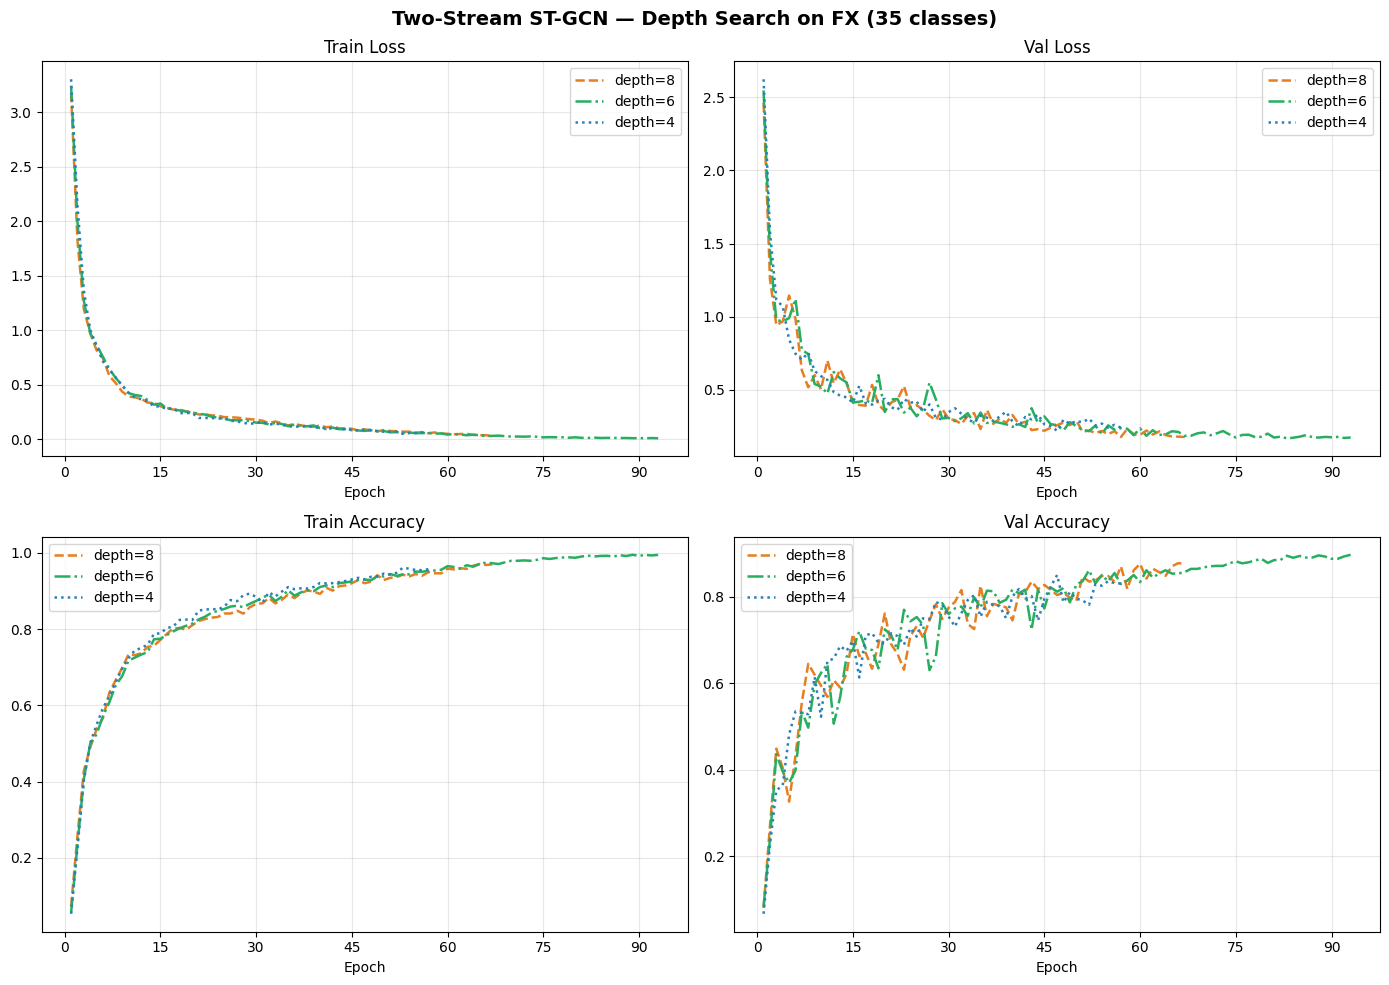

Saved: outputs/depth_search_fx/depth_search_curves.png


In [8]:
# ── Cell 8: So sánh training curves tất cả depths ────────────────────────────
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLORS = {8: '#e67e22', 6: '#27ae60', 4: '#2980b9'}
STYLES = {8: '--',      6: '-.',      4: ':'}

histories = {}
for d in DEPTHS:
    h_path = Path(DEPTH_OUT_DIRS[d]) / 'history.json'
    if h_path.exists():
        with open(h_path) as f:
            histories[d] = json.load(f)
        print(f'[depth={d}] Loaded history ({len(histories[d]["val_acc"])} epochs)')
    else:
        print(f'[depth={d}] history.json not found, skipping.')

if not histories:
    print('No histories loaded — run the training cells first.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Two-Stream ST-GCN — Depth Search on FX (35 classes)', fontsize=14, fontweight='bold')

    plot_cfg = [
        (axes[0, 0], 'train_loss', 'Train Loss'),
        (axes[0, 1], 'val_loss',   'Val Loss'),
        (axes[1, 0], 'train_acc',  'Train Accuracy'),
        (axes[1, 1], 'val_acc',    'Val Accuracy'),
    ]

    for ax, key, title in plot_cfg:
        for d, h in sorted(histories.items(), reverse=True):
            if key in h:
                epochs = range(1, len(h[key]) + 1)
                ax.plot(epochs, h[key],
                        color=COLORS[d], linestyle=STYLES[d],
                        linewidth=1.8, label=f'depth={d}')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    out_png = Path(OUT_BASE) / 'depth_search_curves.png'
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_png}')

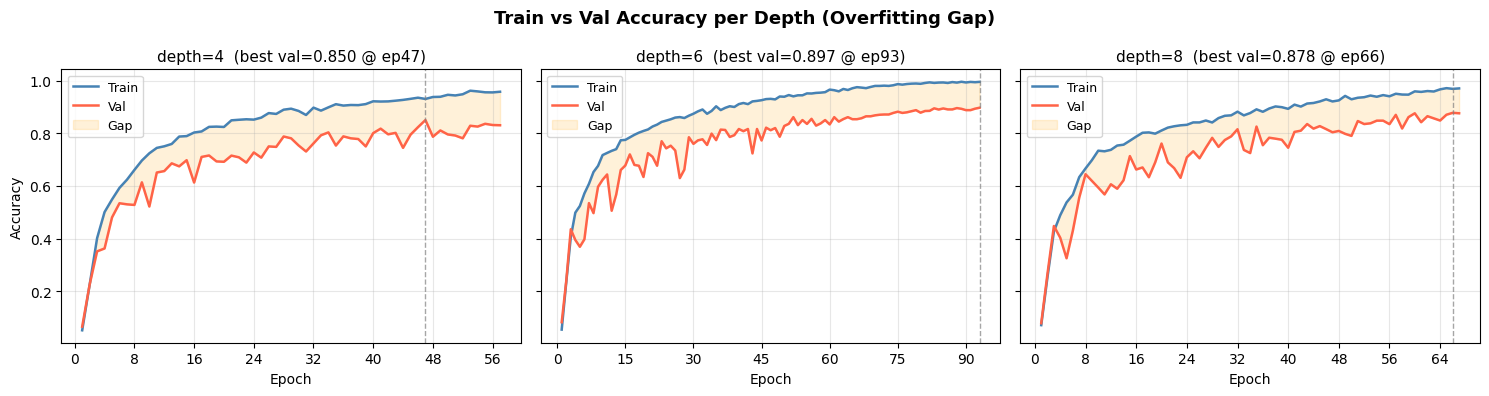

Saved: outputs/depth_search_fx/depth_search_gap.png


In [9]:
# ── Cell 10: Overfitting gap — train acc vs val acc ───────────────────────────
# Plot riêng để dễ thấy gap giữa train và val cho từng depth

if not histories:
    print('No histories loaded — run the training cells first.')
else:
    n_depths = len(histories)
    fig, axes = plt.subplots(1, n_depths, figsize=(5 * n_depths, 4), sharey=True)
    if n_depths == 1:
        axes = [axes]
    fig.suptitle('Train vs Val Accuracy per Depth (Overfitting Gap)', fontsize=13, fontweight='bold')

    for ax, (d, h) in zip(axes, sorted(histories.items())):
        epochs = range(1, len(h['train_acc']) + 1)
        ax.plot(epochs, h['train_acc'], color='steelblue', linewidth=1.8, label='Train')
        ax.plot(epochs, h['val_acc'],   color='tomato',    linewidth=1.8, label='Val')
        ax.fill_between(epochs, h['val_acc'], h['train_acc'],
                        alpha=0.15, color='orange', label='Gap')

        best_val   = max(h['val_acc'])
        best_epoch = h['val_acc'].index(best_val) + 1
        ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_title(f'depth={d}  (best val={best_val:.3f} @ ep{best_epoch})', fontsize=11)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    axes[0].set_ylabel('Accuracy')
    plt.tight_layout()
    out_png = Path(OUT_BASE) / 'depth_search_gap.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_png}')

In [10]:
# ── Cell 11: Bảng tổng kết kết quả ──────────────────────────────────────────
import json

print(f'{'Depth':>6}  {'Best Val Acc':>12}  {'@Epoch':>7}  {'Final Val Acc':>13}  {'Final Train Acc':>15}  {'Gap (final)':>11}  {'Macro F1':>9}')
print('-' * 82)

for d in sorted(histories.keys()):
    h = histories[d]
    best_val   = max(h['val_acc'])
    best_epoch = h['val_acc'].index(best_val) + 1
    final_val  = h['val_acc'][-1]
    final_tr   = h['train_acc'][-1]
    gap        = final_tr - final_val

    # Load macro F1 from metrics file if available
    m_path = Path(DEPTH_OUT_DIRS[d]) / 'metrics_train_gym99.json'
    macro_f1 = '—'
    if m_path.exists():
        with open(m_path) as f:
            m = json.load(f)
        macro_f1 = f"{m.get('macro_f1', 0):.4f}"

    print(f'{d:>6}  {best_val:>12.4f}  {best_epoch:>7}  {final_val:>13.4f}  {final_tr:>15.4f}  {gap:>+11.4f}  {macro_f1:>9}')

 Depth  Best Val Acc   @Epoch  Final Val Acc  Final Train Acc  Gap (final)   Macro F1
----------------------------------------------------------------------------------
     4        0.8501       47         0.8304           0.9574      +0.1270     0.8277
     6        0.8968       93         0.8968           0.9949      +0.0981     0.8719
     8        0.8776       66         0.8757           0.9701      +0.0943     0.8459
